In [2]:
# %pip install ultralytics


In [16]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt


In [5]:
img_path = '../_data/resource/id_swe.jpg'
image = cv2.imread(img_path)


0: 448x640 2 persons, 1 book, 120.0ms
Speed: 22.5ms preprocess, 120.0ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)


In [19]:
# Load object detection model
model = YOLO("yolov8n.pt")

# Select source
source = 'https://ultralytics.com/images/bus.jpg'

# Run inference
results = model(source)

# Get detections from the first image in the batch
detections = results[0].boxes

# Print all detected objects with class name and confidence
for i in range(len(detections)):
    class_index = int(detections.cls[i])
    class_name = results[0].names[class_index]
    confidence = float(detections.conf[i])
    print(f"Detected: {class_name} (index: {class_index}) - Confidence: {confidence:.4f}")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /srv/hl2/Documents/git/hula/CookbookPyCode/image_processing/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 113.1ms
Speed: 5.7ms preprocess, 113.1ms inference, 1.1ms postprocess per image at shape (1, 3, 640, 480)
Detected: bus (index: 5) - Confidence: 0.8734
Detected: person (index: 0) - Confidence: 0.8657
Detected: person (index: 0) - Confidence: 0.8528
Detected: person (index: 0) - Confidence: 0.8252
Detected: person (index: 0) - Confidence: 0.2611
Detected: stop sign (index: 11) - Confidence: 0.2551


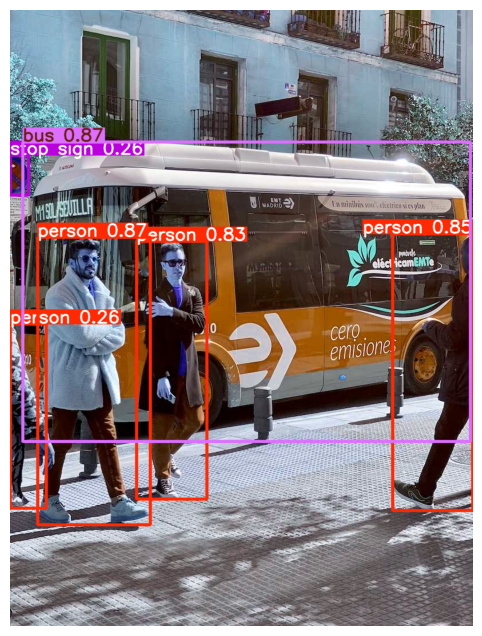

In [21]:
# Get the plotted image as PIL Image
plotted_img = results[0].plot()

# Display using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(plotted_img)
plt.axis('off')
plt.show()

In [17]:
# Load classification model
model = YOLO("yolov8n-cls.pt")

# Select source
source = 'https://ultralytics.com/images/bus.jpg'

# Run inference
results = model(source)

# Get top prediction
top_class_index = results[0].probs.top1
top_class_name = results[0].names[top_class_index]
top_confidence = results[0].probs.top1conf.item()

print(f"Top prediction: {top_class_name} (index: {top_class_index})")
print(f"Confidence: {top_confidence:.4f}")


Found https://ultralytics.com/images/bus.jpg locally at bus.jpg
image 1/1 /srv/hl2/Documents/git/hula/CookbookPyCode/image_processing/bus.jpg: 224x224 minibus 0.50, police_van 0.29, trolleybus 0.05, golfcart 0.02, jinrikisha 0.02, 185.6ms
Speed: 26.4ms preprocess, 185.6ms inference, 0.1ms postprocess per image at shape (1, 3, 224, 224)
Top prediction: minibus (index: 654)
Confidence: 0.5049


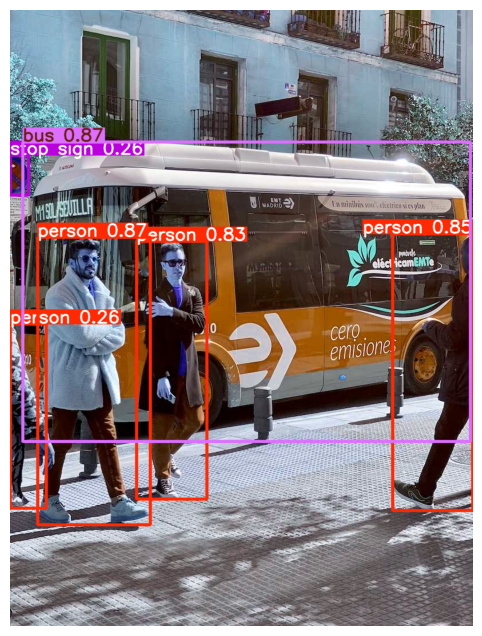

In [23]:
# Get the plotted image as PIL Image
plotted_img = results[0].plot()

# Display using matplotlib
plt.figure(figsize=(12, 8))
plt.imshow(plotted_img)
plt.axis('off')
plt.show()